# LSTM 기반 주가예측모델

## 시계열 데이터 분석 Time Series Data
시계열 데이터란 **시간의 흐름에 따라 관찰하거나 측정한 데이터**를 말한다. 이 데이터는 일반적으로 시간의 순서를 가지며, 특정 시점에서의 값을 나타낸다. 예를 들어, 일일 주식 가격, 시간별 기온, 월별 매출 등이 시계열 데이터의 대표적인 예이다.

**주요 특징**
1. **시간 순서**  
   - 데이터가 시간의 흐름에 따라 정렬되어 있어야 한다. 시간의 순서가 데이터를 분석할 때 중요한 기준이 된다.
2. **시간 종속성**  
   - 이전 시점의 데이터가 이후 시점의 데이터에 영향을 미칠 수 있다.
3. **패턴과 추세**  
   - 주기적인 패턴(계절성)이나 장기적인 변화(추세)를 포함할 수 있다.
4. **불확실성**  
   - 시계열 데이터는 종종 노이즈(잡음)를 포함하며, 예측이 어려울 수 있다.

**활용**
- **금융**: 주식 가격, 환율 변동
- **기상**: 기온, 강수량 예측
- **경제**: GDP, 실업률 변화
- **소비자 행동**: 웹사이트 방문 트래픽, 제품 판매 데이터

**분석 및 모델링 방법**
- **EDA (탐색적 데이터 분석)**  
  - 데이터 시각화, 계절성, 추세 확인
- **통계적 모델링**  
  - ARIMA, SARIMA 등
- **머신러닝**  
  - 시계열 데이터에 특화된 RNN, LSTM, Transformer 등을 활용

시계열 데이터는 과거 데이터를 기반으로 미래를 예측하거나 현재의 상태를 분석하는 데 중요한 역할을 한다.

In [1]:
%pip install finance-datareader

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 61.4 MB/s  0:00:00

   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import FinanceDataReader as fdr

## 주가 데이터 가져오기

In [3]:
# 회사별 주식 코드(ticker)
samsung_code = '005930'
samsung = fdr.DataReader(samsung_code)
samsung
# Open : 시가
# High : 고가
# Low : 저가
# Close : 종가
# Volume : 거래량
# Change : 전날 대비 변화량

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-02-06,24900,25340,24800,25180,303949,NaN
2014-02-07,25500,25580,25260,25500,198872,0.012708
2014-02-10,25420,25620,25240,25540,155993,0.001569
2014-02-11,25620,26300,25440,26220,253680,0.026625
2014-02-12,26620,26620,26100,26140,200548,-0.003051
...,...,...,...,...,...,...
2026-04-21,218000,220000,216000,219000,16752132,0.020979
2026-04-22,218500,222500,215500,217500,16823480,-0.006849
2026-04-23,223000,229500,216000,224500,34525485,0.032184


In [4]:
apple = fdr.DataReader('AAPL', '2017-01-01', '2017-12-31')
apple

,Open,High,Low,Close,Volume,Adj Close
2017-01-03,28.950001,29.082500,28.690001,29.037500,115127600,26.745859
2017-01-04,28.962500,29.127501,28.937500,29.004999,84472400,26.715919
2017-01-05,28.980000,29.215000,28.952499,29.152500,88774400,26.851776
2017-01-06,29.195000,29.540001,29.117500,29.477501,127007600,27.151129
2017-01-09,29.487499,29.857500,29.485001,29.747499,134247600,27.399824
...,...,...,...,...,...,...
2017-12-22,43.669998,43.855000,43.625000,43.752499,65397600,40.947594
2017-12-26,42.700001,42.867500,42.419998,42.642502,132742000,39.908752
2017-12-27,42.525002,42.695000,42.427502,42.650002,85992800,39.915787
2017-12-28,42.750000,42.962502,42.619999,42.770000,65920800,40.028084


## 주식데이터 시각화

In [5]:
naver_code = '035420'
naver = fdr.DataReader(naver_code)
naver.index

DatetimeIndex(['2014-02-06', '2014-02-07', '2014-02-10', '2014-02-11',
               '2014-02-12', '2014-02-13', '2014-02-14', '2014-02-17',
               '2014-02-18', '2014-02-19',
               ...
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23',
               '2026-04-24', '2026-04-27'],
              dtype='datetime64[us]', name='Date', length=3000, freq=None)

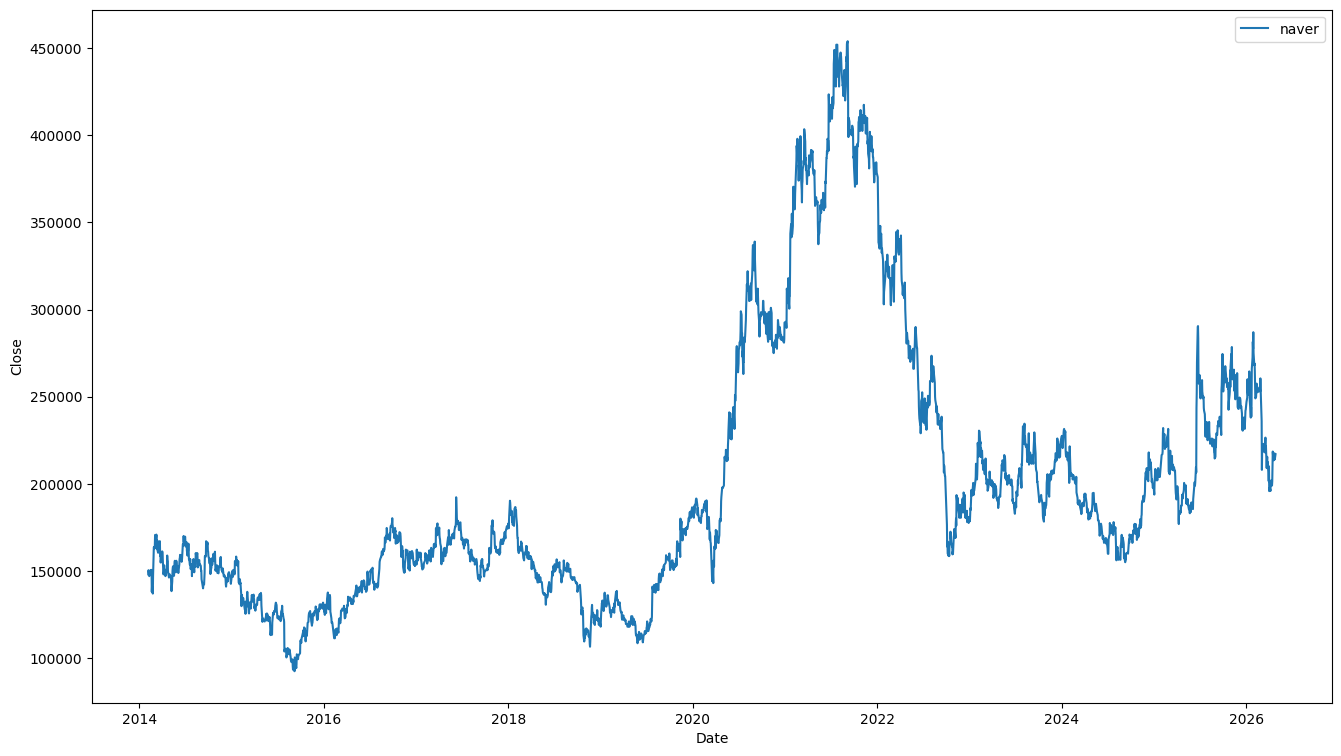

In [6]:
plt.figure(figsize=(16, 9))
plt.plot(naver.index, naver['Close'], label='naver')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.show()

## 학습데이터 생성

In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import torch

# 종가 데이터 추출
prices = naver['Close'].values.reshape(-1, 1)

# 입력으로 사용할 과거 일수
window_size = 20

# 원본 시계열 기준으로 학습/검증 분리
train_size_raw = int(len(prices) * 0.8)

train_prices = prices[:train_size_raw]

# 검증 데이터의 첫 번째 입력 window를 만들기 위해 검증 시작 지점 window_size일을 함께 포함
val_prices = prices[train_size_raw - window_size:]

print(train_prices.shape)
print(val_prices.shape)

(2400, 1)
(620, 1)


In [9]:
# 스케일링 - fit은 학습 데이터에만 수행
scaler = MinMaxScaler()

train_prices_scaled = scaler.fit_transform(train_prices).flatten()
val_prices_scaled = scaler.transform(val_prices).flatten()

print(train_prices_scaled[:5])
print(val_prices_scaled[:5])

[0.1537134  0.1603622  0.15094491 0.15260711 0.15482245]
[0.27814608 0.27980551 0.27482721 0.26901919 0.26570032]


In [10]:
def create_dataset(data, window_size=20):
    X, y = [], []

    # window는 모델이 한 번에 참고할 과거 데이터 개수이다.
    for i in range(len(data) - window_size):
        # i번째 시점부터 window_size 개만큼의 데이터를 입력 값으로 사용
        inputs = data[i: i + window_size]
        # 입력 구간 바로 다음 시점의 값을 정답 값으로 사용
        labels = data[i + window_size]

        X.append(inputs)
        y.append(labels)
    
    return np.array(X), np.array(y)

# 학습, 검증 데이터를 각각 window 형태로 변환
X_train, y_train = create_dataset(train_prices_scaled, window_size)
X_val, y_val = create_dataset(val_prices_scaled, window_size)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(2380, 20) (2380,)
(600, 20) (600,)


In [11]:
# 생성 된 window 데이터 확인
df_train = pd.DataFrame(X_train)
df_train['target'] = y_train
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,target
0,0.153713,0.160362,0.150945,0.152607,0.154822,0.158700,0.159809,0.159253,0.160915,0.159809,...,0.134882,0.123249,0.151498,0.165346,0.183074,0.196922,0.194704,0.199691,0.216310,0.207446
1,0.160362,0.150945,0.152607,0.154822,0.158700,0.159809,0.159253,0.160915,0.159809,0.126017,...,0.123249,0.151498,0.165346,0.183074,0.196922,0.194704,0.199691,0.216310,0.207446,0.201906
2,0.150945,0.152607,0.154822,0.158700,0.159809,0.159253,0.160915,0.159809,0.126017,0.134882,...,0.151498,0.165346,0.183074,0.196922,0.194704,0.199691,0.216310,0.207446,0.201906,0.216863
3,0.152607,0.154822,0.158700,0.159809,0.159253,0.160915,0.159809,0.126017,0.134882,0.123249,...,0.165346,0.183074,0.196922,0.194704,0.199691,0.216310,0.207446,0.201906,0.216863,0.215201
4,0.154822,0.158700,0.159809,0.159253,0.160915,0.159809,0.126017,0.134882,0.123249,0.151498,...,0.183074,0.196922,0.194704,0.199691,0.216310,0.207446,0.201906,0.216863,0.215201,0.194151


In [12]:
# 텐서 변환
# Conv1d + LSTM 입력을 위해 마지막 차원에 feature 추가
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

X_val = torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([2380, 20, 1]) torch.Size([2380, 1])
torch.Size([600, 20, 1]) torch.Size([600, 1])


## Conv1d 레이어

<img src="https://controlandlearning.wordpress.com/wp-content/uploads/2020/07/figure-1.png" width="500"/>

**1. Conv1d란?**

`nn.Conv1d`는 1차원 시퀀스 데이터를 위한 합성곱 레이어이다.  
예: 시계열 데이터, 텍스트 임베딩 등

**2. 입력/출력 형태**

- 입력 shape: `(batch_size, in_channels, seq_len)`
- 출력 shape: `(batch_size, out_channels, new_seq_len)`

**3. 주요 파라미터**

| 파라미터           | 설명                                        |
| -------------- | ----------------------------------------- |
| `in_channels`  | 입력 채널 수 (예: 임베딩 차원, 또는 이전 conv의 출력 채널 수)  |
| `out_channels` | 출력 채널 수 (필터 개수, convolution 결과 feature 수) |
| `kernel_size`  | 필터 크기 (한 번에 보는 시점의 개수)                    |
| `stride`       | 필터가 이동하는 간격 (기본값=1)                       |
| `padding`      | 입력 시퀀스 앞뒤에 0을 덧붙여서 시퀀스 길이를 조절 (기본값=0)     |


**4.출력길이 계산**

- L: 원래 시퀀스 길이

```
output_length = floor((L + 2 * padding - kernel_size) / stride) + 1
```
위 이미지에서는 패딩이 없으므로 `(5 + 2 * 0 - 2) / 1 + 1 = 4`로 처리

In [19]:
# Conv1d 구조 확인
import torch
import torch.nn as nn 

# LSTM 입력 형태 : (batch_size, seq_len, input_size)
# 1개 샘플, 20일치 데이터, 각 시점의 값 1개
x = torch.randn(1, 20, 1)
print('입력 : ', x.shape)

# Conv1d는 짧은 구간의 패턴을 뽑는 레이어이다.
conv1d = nn.Conv1d(
    in_channels=1,
    out_channels=32,    # 32개의 패턴 특징을 생성
    kernel_size=5,      # 5일씩 묶어서 패턴 확인
    padding=4
)

# Conv1d는 (batch_size, channel, seq_len) 형태를 요구한다
# 따라서 (1, 20, 1) -> (1, 1, 20) 으로 변경한다.
x = x.permute(0, 2, 1)
print('in 차원 변환 : ', x.shape)

# Conv1d 적용
# 결과는 (batch_size, out_channels, new_seq_len)
x = conv1d(x)
print('conv1d 출력 : ', x.shape)

# LSTM은 다시 (batch_size, seq_len, feature_size) 형태를 요구한다
# 따라서 (1, 32, 24) -> (1, 24, 32) 로 변경한다.
x = x.permute(0, 2, 1)
print('out 차원 변환 : ', x.shape)


입력 :  torch.Size([1, 20, 1])
in 차원 변환 :  torch.Size([1, 1, 20])
conv1d 출력 :  torch.Size([1, 32, 24])
out 차원 변환 :  torch.Size([1, 24, 32])


## 모델 생성

In [20]:
import torch.nn as nn

class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, conv_filters, conv_kernel_size):
        super().__init__()

        # Conv1d : 원본 시계열에서 짧은 구간 패턴을 먼저 추출 
        # 예: 5일 단위의 상승/하락/변동 흐름
        self.conv1d = nn.Conv1d(
            input_size,                         # in_channels
            conv_filters,                       # out_channels
            kernel_size=conv_kernel_size,
            padding=conv_kernel_size-1
        )

        # LSTM : Conv1d가 만든 구간별 특징의 시간 흐름을 학습
        self.lstm = nn.LSTM(
            conv_filters,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 입력 : (batch_size, seq_len, input_size)
        # Conv1d 입력 형태로 변경 : (batch_size, input_size, seq_len)
        x = x.permute(0, 2, 1)

        # Conv1d로 짧은 구간 패턴 추출
        # 출력 : (batch_size, conv_filters, new_seq_len)
        x = self.conv1d(x)

        # LSTM 입력 형태로 변경 : (batch_size, new_seq_len, conv_filters)
        x = x.permute(0, 2, 1)

        # LSTM은 Conv1d가 추출한 특징들을 시간 순서대로 읽음
        _, (hidden, _) = self.lstm(x)

        output = self.fc1(hidden[-1])
        output = self.relu(output)
        output = self.fc2(output)

        return output

## 모델 학습

In [21]:
import torch.optim as optim

model = StockLSTM(input_size=1,
                  hidden_size=64,
                  num_layers=2,
                  conv_filters=32,
                  conv_kernel_size=5)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 학습
epochs = 50
batch_size = 32

for epoch in range(epochs):
    model.train()
    # 데이터 순서 섞기
    permutation = torch.randperm(X_train.size()[0])
    train_loss = 0

    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i : i + batch_size]
        X_batch = X_train[indices]
        y_batch = y_train[indices]

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 검증
    model.eval()
    with torch.no_grad():
        output = model(X_val)
        loss = criterion(output, y_val)
        val_loss = loss.item()

    print(f'Epoch {epoch + 1}/{epochs}: '
          f'Train Loss {train_loss:.6f}, '
          f'Val Loss {val_loss:.6f}')

Epoch 1/50: Train Loss 0.485819, Val Loss 0.000571
Epoch 2/50: Train Loss 0.036329, Val Loss 0.000407
Epoch 3/50: Train Loss 0.025695, Val Loss 0.000695
Epoch 4/50: Train Loss 0.033199, Val Loss 0.000371
Epoch 5/50: Train Loss 0.040999, Val Loss 0.000360
Epoch 6/50: Train Loss 0.022099, Val Loss 0.000408
Epoch 7/50: Train Loss 0.034352, Val Loss 0.000369
Epoch 8/50: Train Loss 0.032088, Val Loss 0.000430
Epoch 9/50: Train Loss 0.020948, Val Loss 0.000279
Epoch 10/50: Train Loss 0.021335, Val Loss 0.000638
Epoch 11/50: Train Loss 0.028076, Val Loss 0.000381
Epoch 12/50: Train Loss 0.021959, Val Loss 0.000286
Epoch 13/50: Train Loss 0.019955, Val Loss 0.000257
Epoch 14/50: Train Loss 0.018951, Val Loss 0.000275
Epoch 15/50: Train Loss 0.021602, Val Loss 0.000249
Epoch 16/50: Train Loss 0.019242, Val Loss 0.000237
Epoch 17/50: Train Loss 0.016573, Val Loss 0.000285
Epoch 18/50: Train Loss 0.015783, Val Loss 0.000252
Epoch 19/50: Train Loss 0.017227, Val Loss 0.000229
Epoch 20/50: Train Lo

## 모델 예측/시각화

In [22]:
model.eval()
with torch.no_grad():
    output = model(X_val)
    pred = output.detach().numpy()

# 스케일복원
pred_inverse = scaler.inverse_transform(pred)
y_val = y_val.detach().numpy()
y_val_inverse = scaler.inverse_transform(y_val)

pred_inverse[-1], y_val_inverse[-1]

(array([217240.69], dtype=float32), array([217000.], dtype=float32))

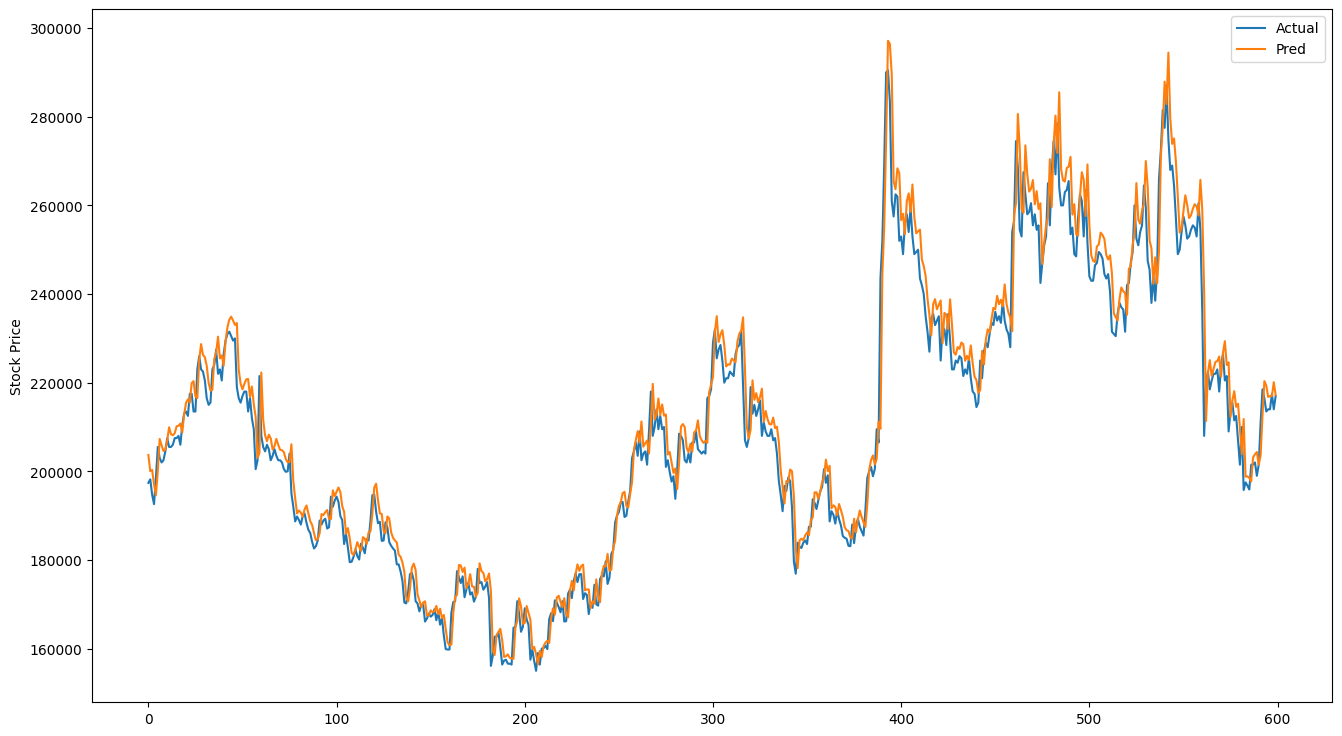

In [23]:
plt.figure(figsize=(16, 9))
plt.plot(y_val_inverse, label='Actual')
plt.plot(pred_inverse, label='Pred')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

## 모델 예측

In [25]:
# 모델 예측
def predict_next_stock_price(data, model, scaler):
    
    # 스케일링
    data_scaled = scaler.transform(data.reshape(-1, 1))
    # 텐서 변환
    data_tensor = torch.tensor(data_scaled, dtype=torch.float).unsqueeze(0)
    print(data_tensor.shape)

    # 모델 예측
    model.eval()
    with torch.no_grad():
        output = model(data_tensor)
        pred = output.detach().numpy()
    
    # 역스케일링
    pred_inverse = scaler.inverse_transform(pred)
    return pred_inverse[-1]

data = naver['Close'].values[-20:] # ndarray
pred_price = predict_next_stock_price(data, model, scaler)
pred_price

torch.Size([1, 20, 1])


array([219693.9], dtype=float32)